In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px  

plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지(윈도우 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False

In [16]:
df = pd.read_csv("../data/OTT.csv")
df.head()

,구분별(1),구분별(2),2025,2025.1,2025.2,2025.3,2025.4,2025.5,2025.6,2025.7,...,2020.2,2020.3,2020.4,2020.5,2020.6,2020.7,2020.8,2020.9,2020.10,2020.11
0,구분별(1),구분별(2),웨이브(Wavve) (%),티빙(Tving) (%),U+모바일 TV (%),네이버 TV(구 네이버NOW) (%),위버스 (%),SOOP(구 아프리카TV) (%),왓챠 (%),카카오 TV (%),...,U+모바일 TV (%),곰TV (%),위버스 (%),SOOP(구 아프리카TV) (%),왓챠 (%),넷플릭스 (%),유튜브(유튜브 프리미엄 구독) (%),시즌 (%),기타 (%),이중에 이용한적 없음 (%)
1,전체,소계,4.1,13.0,0.9,0.1,0.2,0.1,1.5,0.3,...,1.1,0.0,0.1,0.3,0.3,11.6,8.2,0.5,0.0,78.3
2,성별,남자,3.9,12.0,0.8,0.1,0.2,0.0,1.7,0.0,...,1.3,0.0,0.0,0.4,0.2,10.8,9.1,0.4,0.0,77.3
3,성별,여자,4.2,14.1,1.0,0.1,0.2,0.1,1.3,0.5,...,0.8,0.1,0.3,0.1,0.5,12.4,7.2,0.6,0.1,79.3
4,연령,10대,2.3,24.7,1.5,0.0,1.3,0.0,1.4,2.1,...,3.1,0.0,0.0,0.5,0.1,11.4,6.1,2.1,0.0,79.6


In [17]:
df.iloc[0].unique()

<StringArray>
[                   '구분별(1)',                    '구분별(2)',
            '웨이브(Wavve) (%)',             '티빙(Tving) (%)',
              'U+모바일 TV (%)',      '네이버 TV(구 네이버NOW) (%)',
                   '위버스 (%)',        'SOOP(구 아프리카TV) (%)',
                    '왓챠 (%)',                '카카오 TV (%)',
     '쿠팡플레이 (쿠팡와우 이용자만) (%)',                   '라프텔 (%)',
               '스포티비 나우 (%)',               '네이버 치지직 (%)',
                  '넷플릭스 (%)',                '디즈니플러스 (%)',
                '아마존프라임 (%)',                 '애플TV+ (%)',
      '유튜브(유튜브 프리미엄 구독) (%)',         '틱톡(틱톡 라이브 구독) (%)',
                   '펄스픽 (%)',                 '드라마박스 (%)',
           '이중에 이용한적 없음 (%)',                   '곰TV (%)',
 '네이버 시리즈온 (동영상 시청에 한함) (%)',   '카카오페이지 (동영상 시청에 한함) (%)',
                   '트위치 (%)',                    '시즌 (%)',
                    '기타 (%)']
Length: 29, dtype: str

In [18]:
mask_list1 = ['지역', '직업', '학력', '주거형태', '방송이용 유형', '지역유형']
mask_list2 = ['구분별(1)', '구분별(2)', '웨이브(Wavve) (%)', '티빙(Tving) (%)', '왓챠 (%)', '쿠팡플레이 (쿠팡와우 이용자만) (%)', 
              '넷플릭스 (%)','디즈니플러스 (%)', '아마존프라임 (%)', '애플TV+ (%)',
              '유튜브(유튜브 프리미엄 구독) (%)', '이중에 이용한적 없음 (%)']

df = df[~df['구분별(1)'].isin(mask_list1)]
df = df.loc[:, df.iloc[0].isin(mask_list2)]
df['구분별(1)'].unique()
df.iloc[0].unique()

<StringArray>
[               '구분별(1)',                '구분별(2)',        '웨이브(Wavve) (%)',
         '티빙(Tving) (%)',                '왓챠 (%)', '쿠팡플레이 (쿠팡와우 이용자만) (%)',
              '넷플릭스 (%)',            '디즈니플러스 (%)',            '아마존프라임 (%)',
             '애플TV+ (%)',  '유튜브(유튜브 프리미엄 구독) (%)',       '이중에 이용한적 없음 (%)']
Length: 12, dtype: str

In [19]:
# 연도별 열을 하나의 분석용 DataFrame으로 변환
def make_long_df(df):
    common_cols = df.columns[:2].tolist()
    service_row = df.iloc[0]
    data_rows = df.iloc[1:]
    long_parts = []

    for col in df.columns[2:]:
        part = data_rows[common_cols].copy()
        part["연도"] = str(col)[:4]
        part["서비스"] = service_row[col]
        part["이용률"] = pd.to_numeric(data_rows[col], errors="coerce")
        long_parts.append(part)

    return pd.concat(long_parts, ignore_index=True)



df_long = make_long_df(df)
df_long

,구분별(1),구분별(2),연도,서비스,이용률
0,전체,소계,2025,웨이브(Wavve) (%),4.1
1,성별,남자,2025,웨이브(Wavve) (%),3.9
2,성별,여자,2025,웨이브(Wavve) (%),4.2
3,연령,10대,2025,웨이브(Wavve) (%),2.3
4,연령,20대,2025,웨이브(Wavve) (%),8.5
...,...,...,...,...,...
1453,가족구성,1인가구,2020,이중에 이용한적 없음 (%),72.5
1454,가족구성,1세대가구,2020,이중에 이용한적 없음 (%),82.2
1455,가족구성,2세대가구,2020,이중에 이용한적 없음 (%),78.8
1456,가족구성,3세대가구,2020,이중에 이용한적 없음 (%),83.6


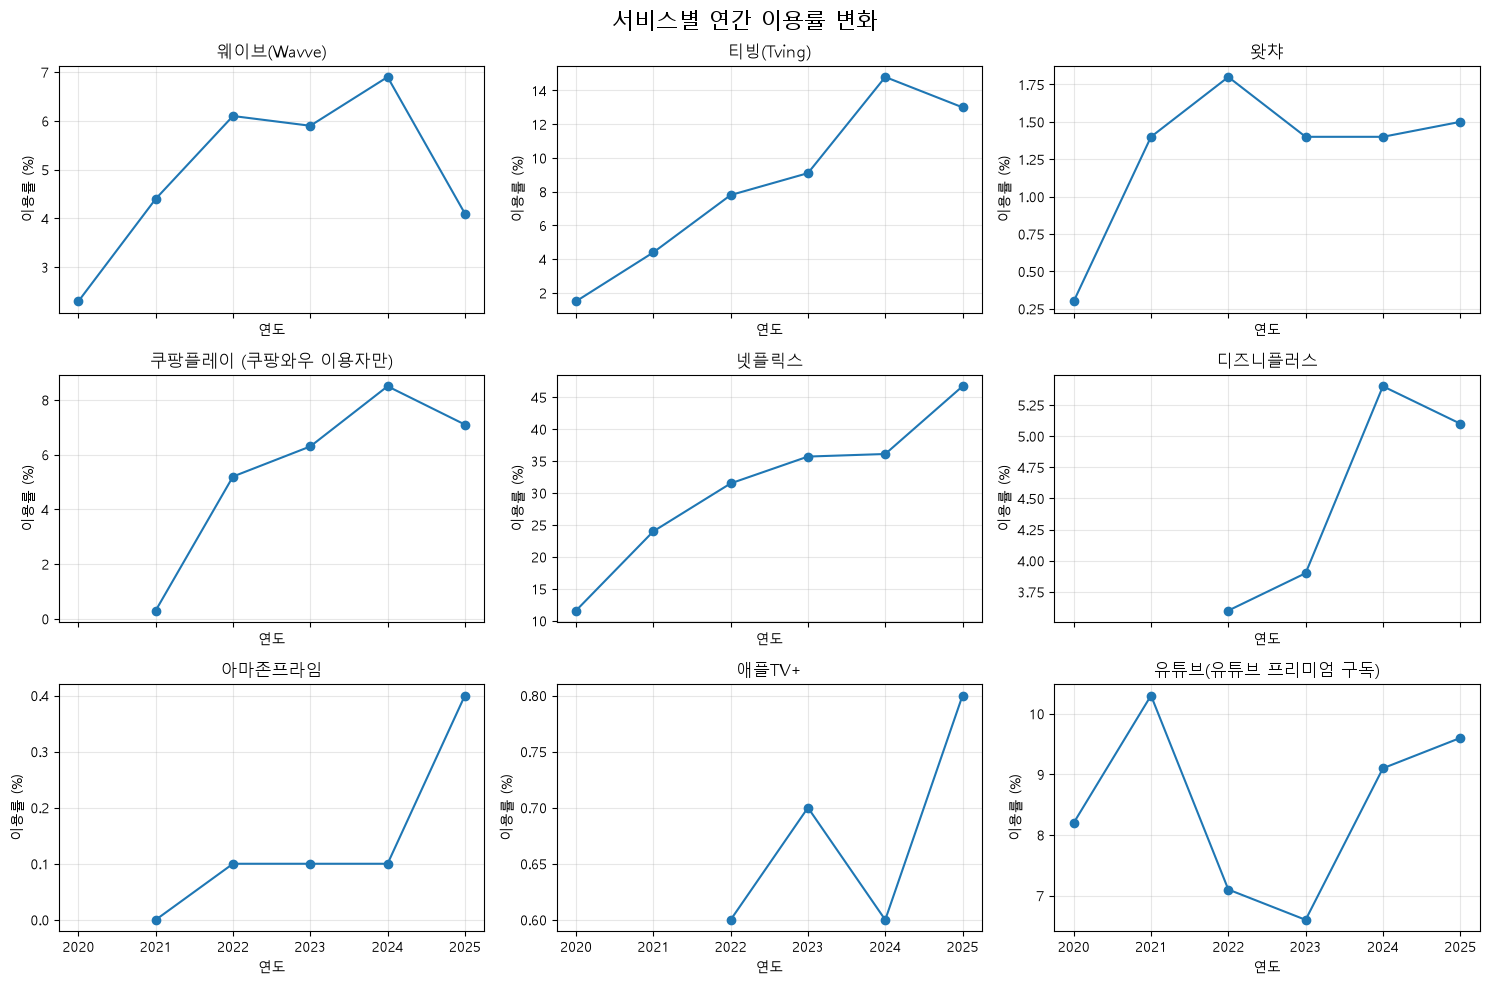

In [20]:
# 전체 응답자(전체·소계)의 서비스 이용률만 추출
overall_usage = df_long[
    (df_long["구분별(1)"] == "전체")
    & (df_long["구분별(2)"] == "소계")
].copy()

# '이용경험 없음'을 제외한 9개 서비스의 연도별 이용률
services = overall_usage.loc[
    ~overall_usage["서비스"].str.contains("이용경험 없음", na=False),
    "서비스",
].unique()

fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)

for ax, service in zip(axes.flat, services):
    yearly_usage = overall_usage[overall_usage["서비스"] == service].sort_values("연도")
    ax.plot(yearly_usage["연도"], yearly_usage["이용률"], marker="o")
    ax.set_title(service.replace(" (%)", ""))
    ax.set_xlabel("연도")
    ax.set_ylabel("이용률 (%)")
    ax.grid(alpha=0.3)

plt.suptitle("서비스별 연간 이용률 변화", fontsize=16)
plt.tight_layout()
plt.show()